In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np

# Embeddings
drug_emb = np.load("Data/drug_chemberta_embeddings.npy")
# adr_emb = np.load("Data/adr_bert_embeddings.npy")

# Names (for indexing)
cid_df = pd.read_csv("Data/drug_ids.csv")       # column: CID
adr_names = pd.read_csv("Data/adr_names.csv")    # column: ADR

# Positive drug-ADR pairs
df_meddra_all_se = pd.read_csv("Data/meddra_all_se.tsv", sep="\t", header=None)
print(df_meddra_all_se.head())
df_meddra_all_se.columns = ["CID", "STITCH_CID", "UMLS_ID", "Source", "Noname","ADR"]
df_meddra_all_se["new_CID"] = df_meddra_all_se["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)
df_meddra_all_indications = pd.read_csv("Data/meddra_all_indications.tsv", sep="\t", header=None,
                 names=["CID", "UMLS_ID", "text", "name", "name2","ID", "name4"])

df_meddra_all_indications["new_CID"] = df_meddra_all_indications["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)

# CUI_list = df_meddra_all_se['UMLS_ID'].unique()
# drug_list = df_meddra_all_se["CID"].unique()

ADR_CUI = pd.read_csv("Data/ADR_CUI_TO_NAME.csv", header=None,
                 names=["CUI","ADR_NAME"])
df_adr_UMLS = pd.read_csv("Data/ADR_Path_Lesk_sim.csv", sep=",", header=None)

# df_meddra_all_se

              0             1         2    3         4                      5
0  CID100000085  CID000010917  C0000729  LLT  C0000729       Abdominal cramps
1  CID100000085  CID000010917  C0000729   PT  C0000737         Abdominal pain
2  CID100000085  CID000010917  C0000737  LLT  C0000737         Abdominal pain
3  CID100000085  CID000010917  C0000737   PT  C0687713  Gastrointestinal pain
4  CID100000085  CID000010917  C0000737   PT  C0000737         Abdominal pain


In [2]:
cid_to_index = {cid: i for i, cid in enumerate(cid_df["CID"].tolist())}
cui_to_index = {adr: i for i, adr in enumerate(ADR_CUI["CUI"].tolist())}



In [3]:

adr_counts = df_meddra_all_se["UMLS_ID"].value_counts()


rare_adr = adr_counts[adr_counts <= 5].index.tolist()
common_adr = adr_counts[adr_counts > 5].index.tolist()

print("Rare ADRs:", len(rare_adr))
print("Common ADRs:", len(common_adr))


Rare ADRs: 2661
Common ADRs: 3207


In [4]:
positive_data = []
# y = []
count = 0
adr_UMLS = df_adr_UMLS.to_numpy()
# (label = 1)
for _, row in df_meddra_all_se.iterrows():
    cid = row["new_CID"]
    adr = row["UMLS_ID"]

    i = cid_to_index.get(cid)
    j = cui_to_index.get(adr)

    if adr in common_adr:
      if i is not None and j is not None and i < drug_emb.shape[0] :#and count != 147467: #only use 50% of data
        # ADR = df_adr_UMLS.iloc[j].tolist()
        count += 1
        emb = np.concatenate([drug_emb[i], adr_UMLS[j]])
        positive_data.append(emb)
        # y.append(1)




In [5]:
import ast
negative_data = []
count = 0

for index, row in df_meddra_all_indications.iterrows():
    # if(count == 0):
        if row['new_CID'] in cid_to_index.keys() and (row['UMLS_ID'] in cui_to_index.keys()) and row['UMLS_ID'] not in rare_adr:
            cid = row["new_CID"]
            adr = row["UMLS_ID"]
            i = cid_to_index.get(cid)
            j = cui_to_index.get(adr)
            if( j < adr_UMLS.shape[0] and i < drug_emb.shape[0]):
                emb = np.concatenate([drug_emb[i], adr_UMLS[j]])    
            # emb = np.concatenate([drug_row, ADR])
            # print(emb[1:100])
            negative_data.append(emb) 

In [6]:
(23128, 294935)
len(negative_data), len(positive_data)

(22140, 287565)

In [7]:
X = positive_data + negative_data
y = [1] * len(positive_data) + [0]*len(negative_data)
len(X), len(y)

(309705, 309705)

In [8]:
import lightgbm as lgb
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = lgb.LGBMClassifier(
    is_unbalance = True,
    num_leaves=31,       
    max_depth=-1,         
    learning_rate=0.05,   
    n_estimators=100      
)


model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 230023, number of negative: 17741
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 19.002695 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 581842
[LightGBM] [Info] Number of data points in the train set: 247764, number of used features: 6613
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.928396 -> initscore=2.562301
[LightGBM] [Info] Start training from score 2.562301


LGBMClassifier(is_unbalance=True, learning_rate=0.05)

In [9]:
import matplotlib.pyplot as plt

def analysis_func(y, y_hat, url=None):
    y = np.array(y, dtype=int)
    y_hat = np.array(y_hat, dtype=int)

    # confusion matrix
    TP = np.sum((y == 1) & (y_hat == 1))
    TN = np.sum((y == 0) & (y_hat == 0))
    FP = np.sum((y == 0) & (y_hat == 1))
    FN = np.sum((y == 1) & (y_hat == 0))

    values = {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}

    recall = round(TP / (TP + FN), 2) if (TP + FN) > 0 else 0.0
    precision = round(TP / (TP + FP), 2) if (TP + FP) > 0 else 0.0
    accuracy = round((TP + TN) / (TP + TN + FP + FN), 2)
    F1 = round((2 * recall * precision) / (recall + precision), 2) if (recall + precision) > 0 else 0.0

    result = {'values': values, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': F1}

    #draw the table
    data = [
        ["Predicted Negative", "Predicted Positive", ""],
        ['FN = ' + str(result['values']['FN']), 'TP = ' + str(result['values']['TP']), "Actual Positive"],
        ['TN = ' + str(result['values']['TN']), 'FP = ' + str(result['values']['FP']), "Actual Negative"]
    ]
    text = ""
    for key, val in result.items():
        if key != 'values':
            text += key + ': ' + str(val) + '    '

    fig, ax = plt.subplots(figsize=(8, 1.5))

    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=data, loc='center', cellLoc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(12)

    table.scale(1, 1.5)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('white')
        if(not(row == 0 and col == 2)):
            if( (row == 0 or col == 2)):
                cell.set_facecolor('#8d84d7')
            else:
                cell.set_facecolor('#ccc9e4')

    # plt.tight_layout(pad=0.01)
    plt.text(-.05, -.06, text)
    if(url != None):
        plt.savefig(url, dpi=200,bbox_inches='tight')
    plt.show()

    return result

In [10]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,auc,roc_curve, confusion_matrix,
    matthews_corrcoef
)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


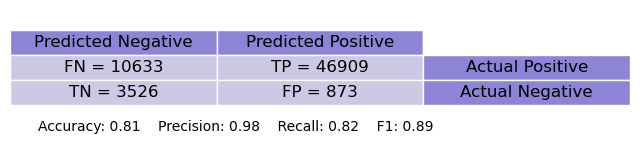

SP: 0.8015458058649693
MCC: 0.37725632452197566
AUR-PR: 0.9902610976957145
Accuracy: 0.814242585686379
ROC-AUC: 0.8946609475776015


In [11]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
analysis_func(y_test, y_pred)

print("SP:", specificity_score(y_test, y_pred))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("AUR-PR:",  average_precision_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

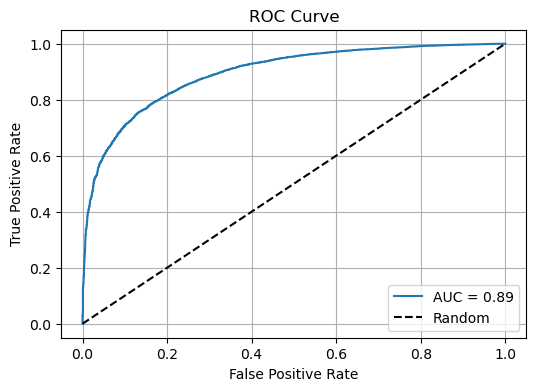

In [12]:

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()